In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
# Load the iris dataset

In [4]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns = iris.feature_names)

In [5]:
# Explore the dataset

In [6]:
print(df.head())
print(df.info())
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000

In [7]:
# Elbow Method

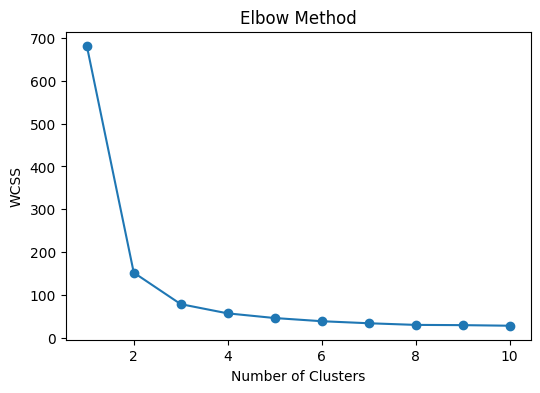

In [8]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
# Apply K-Means

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df)

In [11]:
# Apply PCA

In [12]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df)

In [13]:
# Original Data

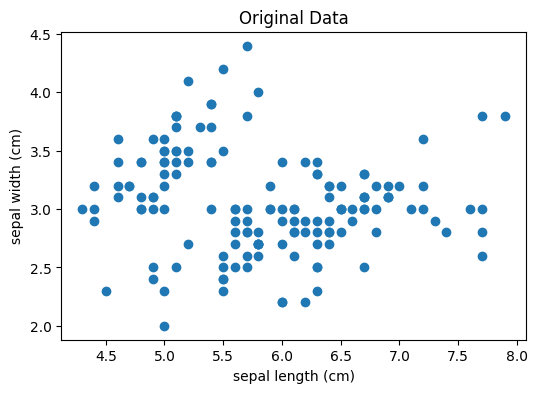

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Original Data")
plt.show()

In [16]:
# K-Means Clusters

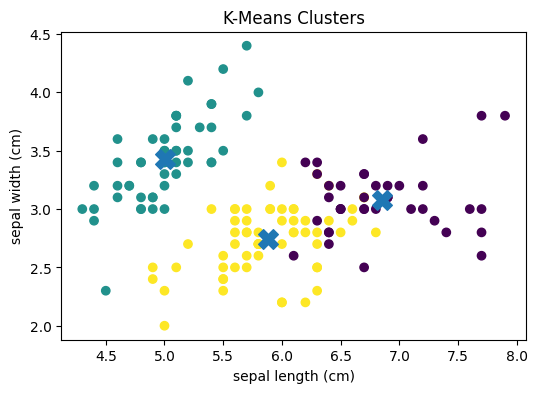

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200)
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("K-Means Clusters")
plt.show()

In [18]:
# PCA Visualization

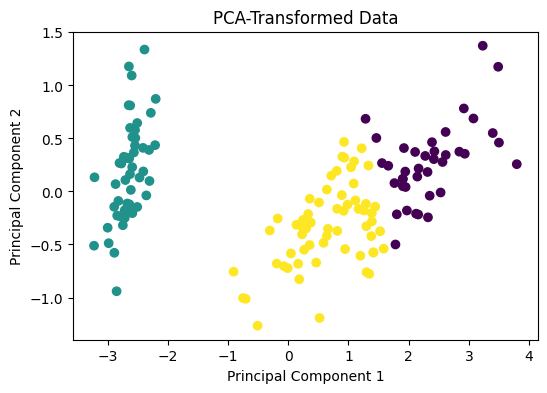

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA-Transformed Data")
plt.show()

In [22]:
# How many clusters were formed?
# 3 clusters were formed.

In [23]:
# Did the clusters represent the flower species well?
# Yes. One species was clearly separated, while the other two had some overlap.

In [24]:
# How did PCA help in visualization?
# PCA reduced the dataset to 2 dimensions, making it easier to visualize the clusters on a scatter plot.